In [13]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.decomposition import PCA
import time
from sklearn.manifold import TSNE



In [ ]:


(x_train, y_train), (_, _) = fashion_mnist.load_data()

num_samples = 2000
x_subset = x_train[:num_samples]
y_subset = y_train[:num_samples]

x_flat = x_subset.reshape(num_samples, -1)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_flat)

print(f"Shape after flattening: {x_flat.shape}")
print(f"Shape after standardization: {x_scaled.shape}")


Shape after flattening: (2000, 784)
Shape after standardization: (2000, 784)


In [5]:
# !pip install tensorflow
# !pip install scikit-learn
# !pip install matplotlib


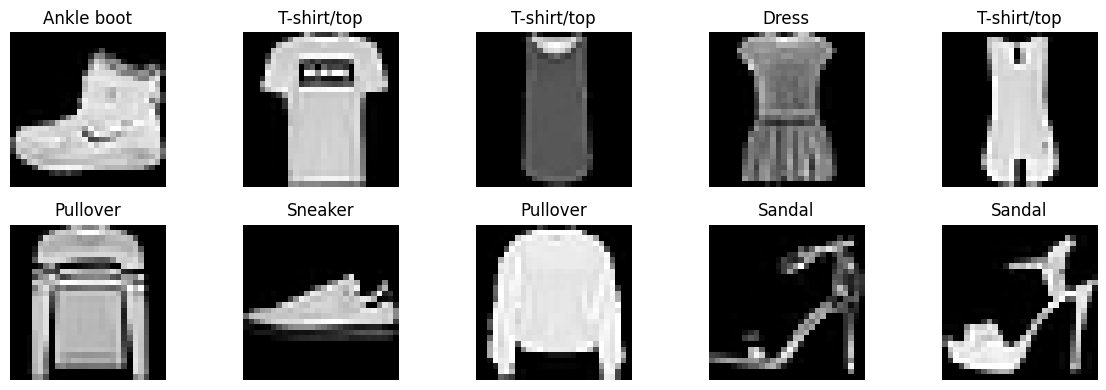

In [ ]:

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print(f"Reduced shape: {x_pca.shape}")


Reduced shape: (2000, 2)


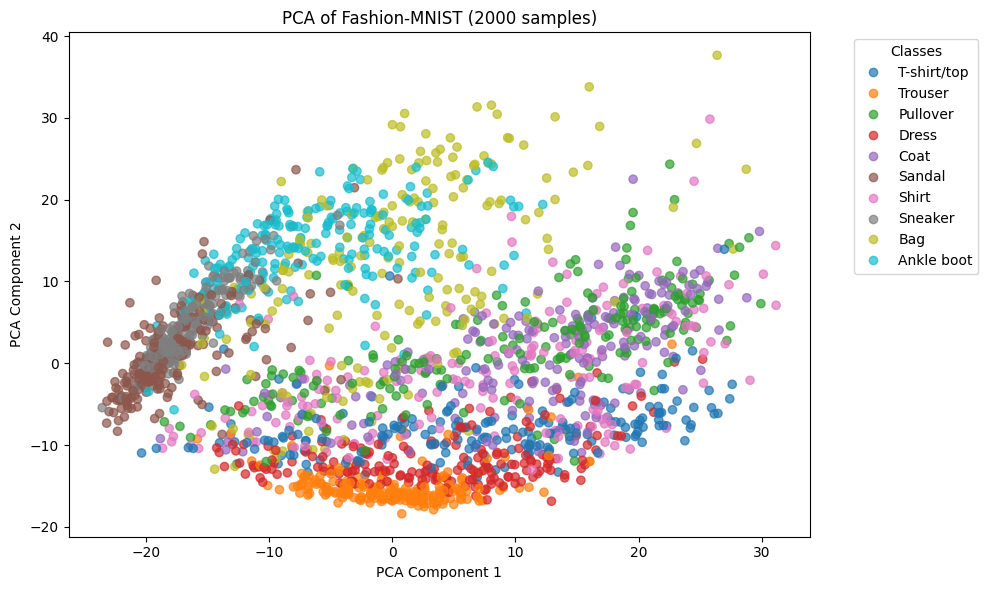

In [8]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_subset, cmap='tab10', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Fashion-MNIST (2000 samples)')

# Add legend for classes
legend_labels = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
handles = scatter.legend_elements()[0]
plt.legend(handles, legend_labels, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)

print(f"t-SNE reduced shape: {x_tsne.shape}")


c:\Users\hwi\Desktop\ML_2\ML-Practice\q2\tf-env\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\hwi\Desktop\ML_2\ML-Practice\q2\tf-env\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\hwi\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\hwi\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\hwi\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 1311, 

t-SNE reduced shape: (2000, 2)


In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)

print(f"Shape after t-SNE reduction: {x_tsne.shape}")


Shape after t-SNE reduction: (2000, 2)


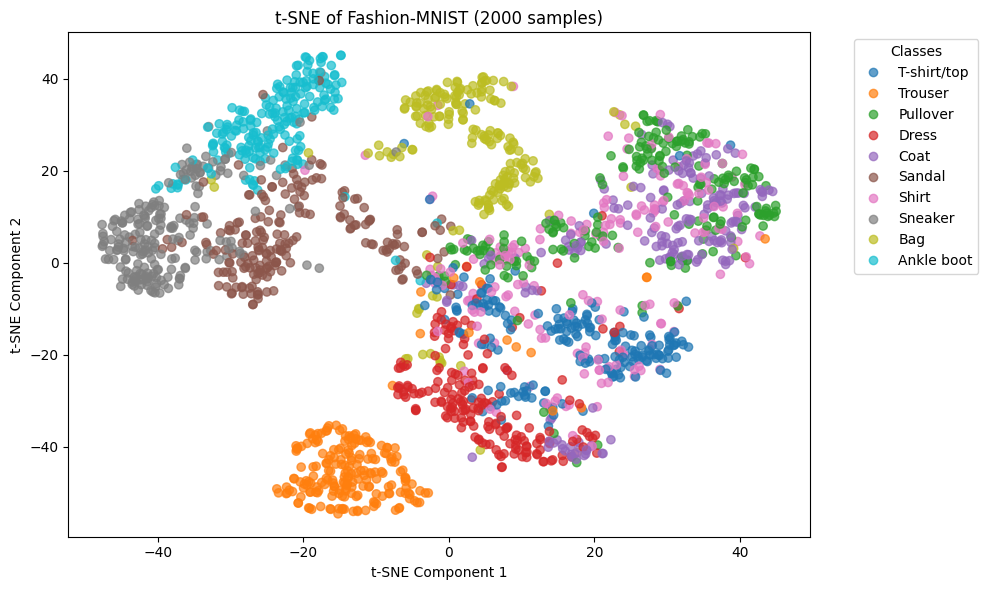

In [11]:

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]


plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c=y_subset, cmap='tab10', alpha=0.7)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of Fashion-MNIST (2000 samples)')


handles = scatter.legend_elements()[0]
plt.legend(handles, class_names, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
start_time = time.time()
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
pca_time = time.time() - start_time

start_time = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)
tsne_time = time.time() - start_time

print(f"Time taken for PCA: {pca_time:.4f} seconds")
print(f"Time taken for t-SNE: {tsne_time:.4f} seconds")


Time taken for PCA: 0.1189 seconds
Time taken for t-SNE: 18.5266 seconds
